In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.svm import SVR
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import ConfusionMatrixDisplay, \
                            precision_score, recall_score, f1_score, roc_auc_score,roc_curve
from scipy.stats import uniform
from sklearn.model_selection import RandomizedSearchCV

## Load the Dataset

In [2]:
df = pd.read_csv(r"C:\Users\hp\Downloads\flood.csv\flood.csv")
df.head(5)

,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,Encroachments,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
0,3,8,6,6,4,4,6,2,3,2,...,10,7,4,2,3,4,3,2,6,0.450
1,8,4,5,7,7,9,1,5,5,4,...,9,2,6,2,1,1,9,1,3,0.475
2,3,10,4,1,7,5,4,7,4,9,...,7,4,4,8,6,1,8,3,6,0.515
3,4,4,2,7,3,4,1,4,6,4,...,4,2,6,6,8,8,6,6,10,0.520
4,3,7,5,2,5,8,5,2,7,5,...,7,6,5,3,3,4,4,3,4,0.475


In [3]:
df.shape

(50000, 21)

In [4]:
df.columns

Index(['MonsoonIntensity', 'TopographyDrainage', 'RiverManagement',
       'Deforestation', 'Urbanization', 'ClimateChange', 'DamsQuality',
       'Siltation', 'AgriculturalPractices', 'Encroachments',
       'IneffectiveDisasterPreparedness', 'DrainageSystems',
       'CoastalVulnerability', 'Landslides', 'Watersheds',
       'DeterioratingInfrastructure', 'PopulationScore', 'WetlandLoss',
       'InadequatePlanning', 'PoliticalFactors', 'FloodProbability'],
      dtype='object')

## Data Preprocessing

In [5]:
# Drop rows with missing target variable values
df.dropna(subset=['FloodProbability'], inplace=True)
# Fill missing values for features, if any (you can use mean, median, or mode)
df.fillna(df.mean(), inplace=True)

## Exploratory Data Analysis (EDA)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   MonsoonIntensity                 50000 non-null  int64  
 1   TopographyDrainage               50000 non-null  int64  
 2   RiverManagement                  50000 non-null  int64  
 3   Deforestation                    50000 non-null  int64  
 4   Urbanization                     50000 non-null  int64  
 5   ClimateChange                    50000 non-null  int64  
 6   DamsQuality                      50000 non-null  int64  
 7   Siltation                        50000 non-null  int64  
 8   AgriculturalPractices            50000 non-null  int64  
 9   Encroachments                    50000 non-null  int64  
 10  IneffectiveDisasterPreparedness  50000 non-null  int64  
 11  DrainageSystems                  50000 non-null  int64  
 12  CoastalVulnerabili

In [7]:
df.describe()

,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,Encroachments,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
count,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,...,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000
mean,4.991480,4.984100,5.01594,5.008480,4.989060,4.988340,5.01536,4.988600,5.006120,5.006380,...,5.006060,4.999920,4.984220,4.97982,4.988200,4.984980,5.00512,4.994360,4.990520,0.499660
std,2.236834,2.246488,2.23131,2.222743,2.243159,2.226761,2.24500,2.232642,2.234588,2.241633,...,2.238107,2.247101,2.227741,2.23219,2.231134,2.238279,2.23176,2.230011,2.246075,0.050034
min,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,0.285000
25%,3.000000,3.000000,3.00000,3.000000,3.000000,3.000000,3.00000,3.000000,3.000000,3.000000,...,3.000000,3.000000,3.000000,3.00000,3.000000,3.000000,3.00000,3.000000,3.000000,0.465000
50%,5.000000,5.000000,5.00000,5.000000,5.000000,5.000000,5.00000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.00000,5.000000,5.000000,5.00000,5.000000,5.000000,0.500000
75%,6.000000,6.000000,6.00000,6.000000,6.000000,6.000000,6.00000,6.000000,6.000000,6.000000,...,6.000000,6.000000,6.000000,6.00000,6.000000,6.000000,6.00000,6.000000,6.000000,0.535000
max,16.000000,18.000000,16.00000,17.000000,17.000000,17.000000,16.00000,16.000000,16.000000,18.000000,...,17.000000,17.000000,16.000000,16.00000,17.000000,19.000000,22.00000,16.000000,16.000000,0.725000


In [8]:
df.isnull().sum() # Check for missing values

MonsoonIntensity                   0
TopographyDrainage                 0
RiverManagement                    0
Deforestation                      0
Urbanization                       0
ClimateChange                      0
DamsQuality                        0
Siltation                          0
AgriculturalPractices              0
Encroachments                      0
IneffectiveDisasterPreparedness    0
DrainageSystems                    0
CoastalVulnerability               0
Landslides                         0
Watersheds                         0
DeterioratingInfrastructure        0
PopulationScore                    0
WetlandLoss                        0
InadequatePlanning                 0
PoliticalFactors                   0
FloodProbability                   0
dtype: int64

## Feature Engineering

In [9]:
# Separate features and target
X = df.drop('FloodProbability', axis=1)  # replace 'target' with the actual column name of your labels
y = df['FloodProbability']

In [10]:
# Standardize features
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

In [11]:
# Feature Selection (top k features)
selector = SelectKBest(score_func=f_classif, k=12)
X_selected_array = selector.fit_transform(X_scaled, y)

In [12]:
# Get selected feature names
selected_columns = X_scaled.columns[selector.get_support()]

# Create final DataFrame with selected features
df_selected = pd.DataFrame(X_selected_array, columns=selected_columns)

# Optionally, include the target back in the DataFrame
df_selected['FloodProbability'] = y.reset_index(drop=True)

In [13]:
df_selected

,MonsoonIntensity,TopographyDrainage,RiverManagement,DamsQuality,Siltation,IneffectiveDisasterPreparedness,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
0,-0.890321,1.342509,0.441028,0.438597,-1.338607,-0.002255,-1.334944,-0.891125,-0.440066,-0.898457,-1.342769,0.449446,0.450
1,1.345004,-0.438066,-0.007144,-1.788597,0.005106,0.446970,-1.334944,-1.787539,-1.780394,1.790031,-1.791202,-0.886231,0.475
2,-0.890321,2.232796,-0.455316,-0.452281,0.900915,-1.349932,1.353026,0.453496,-1.780394,1.341950,-0.894336,0.449446,0.515
3,-0.443256,-0.438066,-1.351659,-1.788597,-0.442798,1.794647,0.457036,1.349910,1.347039,0.445787,0.450962,2.230349,0.520
4,-0.890321,0.897365,-0.007144,-0.006842,-1.338607,0.896196,-0.886949,-0.891125,-0.440066,-0.450375,-0.894336,-0.441005,0.475
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,-0.890321,0.897365,-0.455316,-0.452281,0.453010,-0.451481,1.353026,0.453496,-1.780394,-0.002294,-0.445904,-1.331456,0.535
49996,-0.890321,2.232796,-0.903487,-0.452281,-0.442798,1.345421,0.457036,-0.442918,-0.440066,-1.346538,-0.445904,0.004221,0.510
49997,-0.443256,-0.438066,-0.007144,-0.452281,0.005106,0.896196,-1.782939,0.005289,-1.780394,0.445787,-0.445904,-0.886231,0.430
49998,-0.443256,0.007078,-0.455316,2.220352,-1.338607,-0.002255,0.905031,0.453496,-1.333618,-0.450375,-2.239635,2.675575,0.515


## Visualization

### Heatmap for Correlation

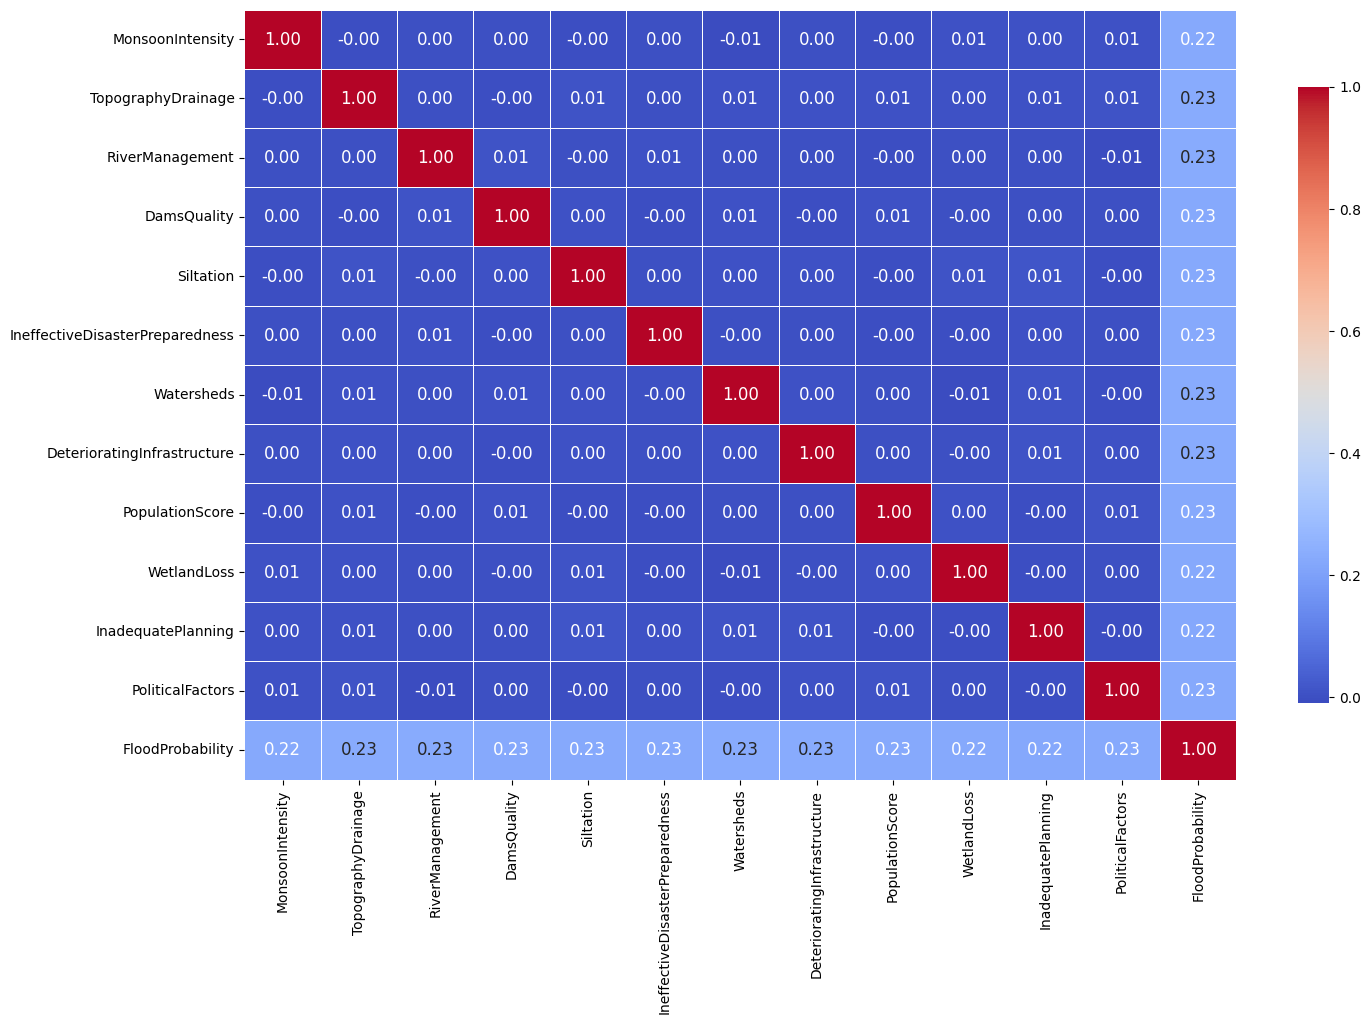

In [14]:
plt.figure(figsize=(16, 10))
sns.heatmap(df_selected.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, annot_kws={"size": 12}, cbar_kws={"shrink": 0.8})
plt.show()

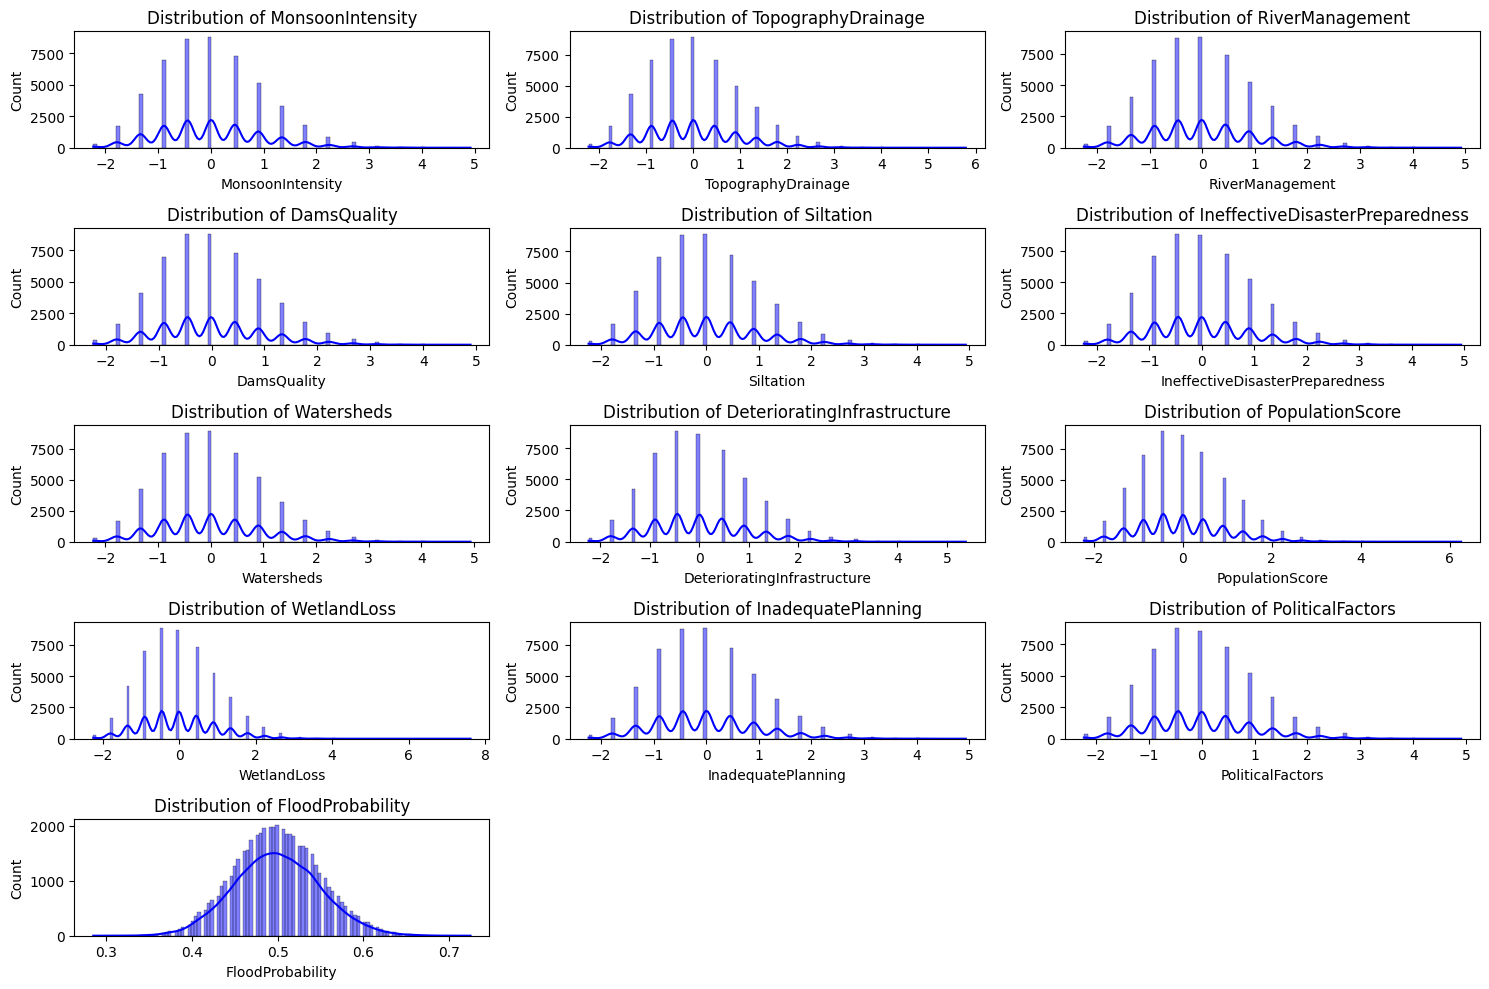

In [15]:
# Select numerical columns
numerical_columns = df_selected.select_dtypes(include=['float64', 'int64']).columns

# Define the number of columns per row
num_cols = 3

# Histograms
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_columns, 1):
    plt.subplot(len(numerical_columns) // num_cols + 1, num_cols, i)
    sns.histplot(df_selected[col], kde=True, color='blue')
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

### Boxplots(to detect and remove outlier)

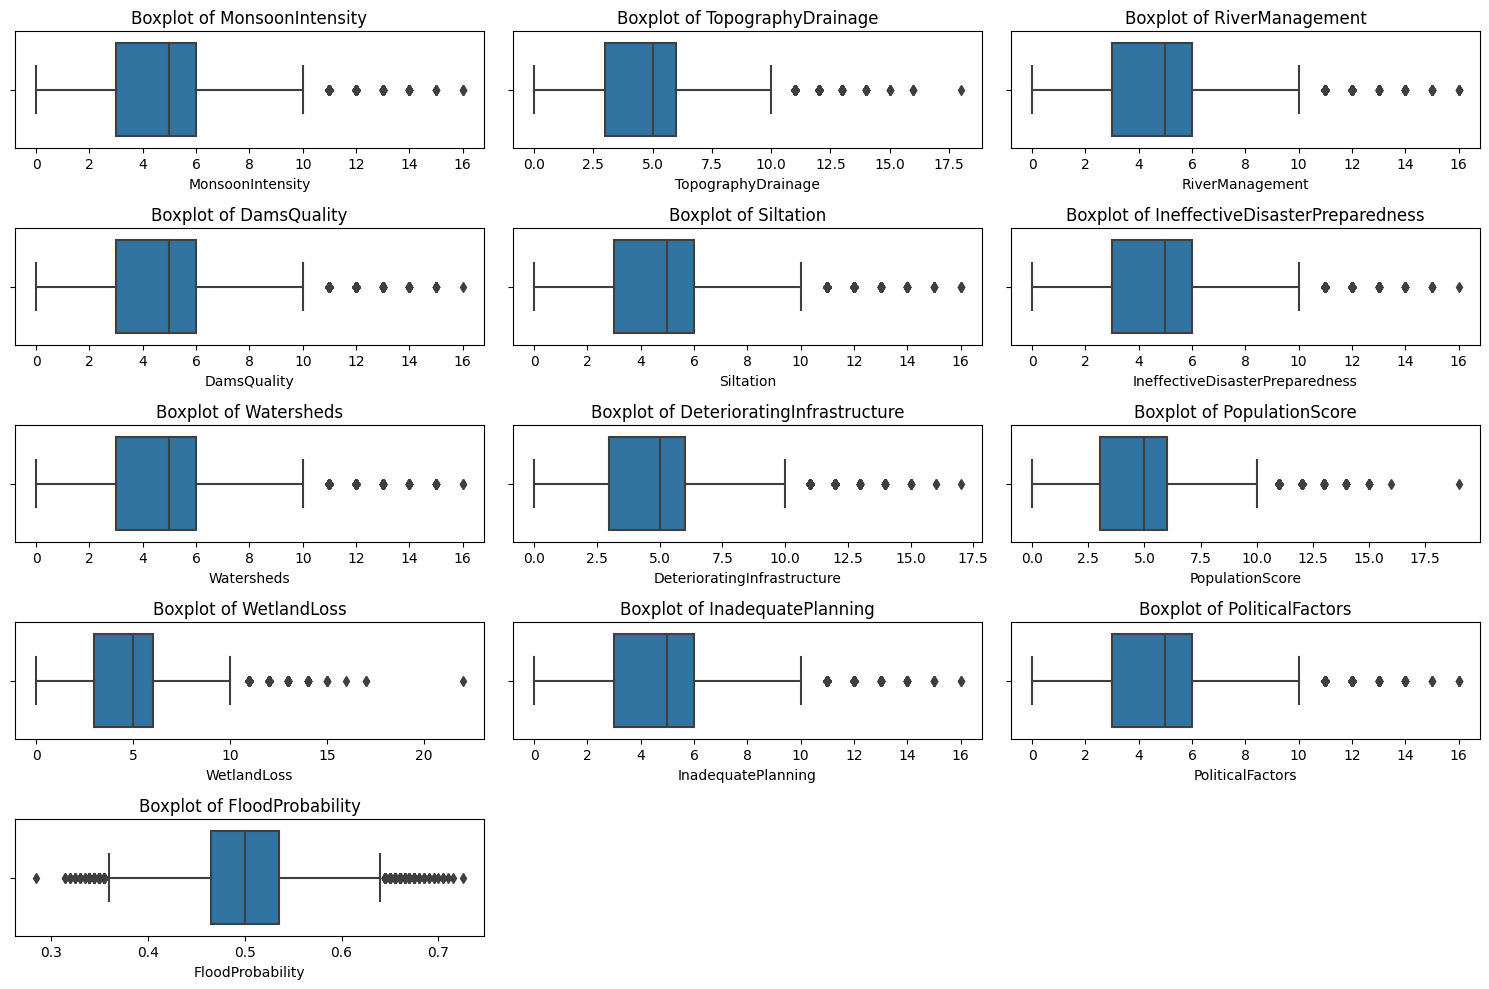

In [16]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_columns, 1):
    plt.subplot(len(numerical_columns) // num_cols + 1, num_cols, i)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

In [17]:
# IQR Method
Q1 = df_selected.quantile(0.25)
Q3 = df_selected.quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Remove outliers
data = df_selected[~((df_selected < lower_bound) | (df_selected > upper_bound)).any(axis=1)]

In [18]:
data.shape

(42206, 13)

In [19]:
# Separate features (X) and target variable (y)
X0 = df.drop('FloodProbability', axis=1)
y0 = df['FloodProbability']

In [20]:
## Binary classification
y0 = (y0 >= 0.5).astype(int)

In [21]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X0, y0, test_size=0.3, random_state=42)

In [22]:
# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [23]:
import warnings
warnings.filterwarnings("ignore")

## Machine Learning Models Implemented with Validation and Hyperparameter tunnning 

### Logistic Regression

In [24]:
# Train model
model = LogisticRegression(C=.00001)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print("Classification Report:\n", classification_report(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]))

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.77      0.87      7334
           1       0.82      1.00      0.90      7666

    accuracy                           0.89     15000
   macro avg       0.91      0.89      0.89     15000
weighted avg       0.91      0.89      0.89     15000

R² Score: 0.5579167636326874
Confusion Matrix:
 [[5677 1657]
 [   0 7666]]
ROC AUC Score: 0.9999615633927262


## KNN (K-Nearest Neighbors)

In [25]:
knn = KNeighborsClassifier()
param_dist = {
    'n_neighbors': list(range(2, 20)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knn_random = RandomizedSearchCV(knn, param_distributions=param_dist, cv=5, scoring='accuracy', random_state=42)
knn_random.fit(X_train, y_train)

print("KNN:")
print("Train Accuracy:", knn_random.score(X_train, y_train))
print("Test Accuracy:", knn_random.score(X_test, y_test))

y_pred = knn_random.predict(X_test)
print(classification_report(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

KNN:
Train Accuracy: 0.9152857142857143
Test Accuracy: 0.8942666666666667
              precision    recall  f1-score   support

           0       0.85      0.96      0.90      7334
           1       0.95      0.83      0.89      7666

    accuracy                           0.89     15000
   macro avg       0.90      0.90      0.89     15000
weighted avg       0.90      0.89      0.89     15000

R² Score: 0.5768593766574788
Confusion Matrix:
 [[7018  316]
 [1270 6396]]


## Random Forest(RF)

In [26]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
param_dist = {
    'n_estimators': [50,100],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2']
}

rf_random = RandomizedSearchCV(rf, param_distributions=param_dist, cv=3, scoring='accuracy',n_jobs=-1, random_state=42)
rf_random.fit(X_train, y_train)

print("Random Forest:")
print("Train Accuracy:", rf_random.score(X_train, y_train))
print("Test Accuracy:", rf_random.score(X_test, y_test))

y_pred = rf_random.predict(X_test)
print(classification_report(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Random Forest:
Train Accuracy: 0.9999142857142858
Test Accuracy: 0.9031333333333333
              precision    recall  f1-score   support

           0       0.91      0.89      0.90      7334
           1       0.90      0.92      0.91      7666

    accuracy                           0.90     15000
   macro avg       0.90      0.90      0.90     15000
weighted avg       0.90      0.90      0.90     15000

R² Score: 0.6123434264081441
Confusion Matrix:
 [[6525  809]
 [ 644 7022]]
